# IMDb Top 1000 Movies & TV Shows
## Unit 3 Final Project — Data Exploration & Dashboard Development

---

**Dataset:** IMDb Top 1000 Movies and TV Shows  
**Source:** [Kaggle — harshitshankhdhar](https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows)  
**Format:** CSV | **Rows:** ~1,000 | **Columns:** 16  

---

### Project Outline
1. Dataset Description & Problem Definition
2. Data Loading & Structure
3. Data Cleaning & Preprocessing
4. Exploratory Data Analysis (EDA)
5. Insights Summary
6. Machine Learning Models
7. Final Summary & Recommendations

---
##Step 1 — Dataset Description & Problem Definition

### What is this dataset about?
This dataset contains information about the **Top 1,000 movies and TV shows** listed on IMDb (Internet Movie Database). It includes details such as movie title, release year, genre, director, cast, runtime, age certificate, IMDb rating, Metascore (critic rating), number of user votes, and gross box office revenue.

### Main Questions We Will Explore
- What factors most influence a movie's IMDb rating?
- Which genres and directors generate the highest box office revenue?
- Has average movie quality (rating) changed over the decades?
- Which genres dominate the Top 1000?
- Do critic scores (Metascore) agree with audience scores (IMDb Rating)?
- Can we predict IMDb Rating or Box Office success using ML?

### What Insights Do We Expect?
- Strong correlation between number of votes and revenue
- Drama and Action likely dominate genre distribution
- Movies from the 1990s–2010s probably score highest on average
- Metascore and IMDb Rating will have moderate but imperfect correlation
- Runtime will have a positive relationship with IMDb rating (longer = more serious)

---
## Step 2A — Install & Import Libraries

In [2]:

# libraries
import pandas as pd #data manipulation
import numpy as np #numerical operations
#warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt #plotting
#import matplotlib.ticker as mticker
import seaborn as sns #statistical visualization
from matplotlib.gridspec import GridSpec

# Styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
COLORS = ['#2E75B6','#E15759','#F28E2B','#76B7B2','#59A14F','#EDC948','#B07AA1','#FF9DA7']

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, classification_report, confusion_matrix
)

print('All libraries imported successfully')

All libraries imported successfully


---
## Step 2B — Load the Dataset

> **How to get the data:**  
> 1. Download `imdb_top_1000.csv` from [Kaggle](https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows)  
> 2. Upload it to this Colab session using the cell below  
> **OR** mount your Google Drive if the file is saved there

In [3]:
import pandas as pd

df_raw = pd.read_csv("imdb_top_1000.csv")

---
## Step 3 — Data Structure

In [4]:
# Shape
print(f' Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')

 Shape: 1000 rows × 16 columns


In [5]:
# Data types & non-null counts
print('═' * 60)
print('  DATA TYPES & INFO')
print('═' * 60)
df_raw.info()

════════════════════════════════════════════════════════════
  DATA TYPES & INFO
════════════════════════════════════════════════════════════
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15 

In [6]:
# Statistical summary
print('═' * 60)
print('  STATISTICAL SUMMARY')
print('═' * 60)
df_raw.describe(include='all')

════════════════════════════════════════════════════════════
  STATISTICAL SUMMARY
════════════════════════════════════════════════════════════


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
count,1000,1000,1000,899,1000,1000,1000.000000,1000,843.000000,1000,1000,1000,1000,1000,1.000000e+03,831
unique,1000,999,100,16,140,202,NaN,1000,NaN,548,660,841,891,939,NaN,823
top,https://m.media-amazon.com/images/M/MV5BMDFkYT...,Drishyam,2014,U,100 min,Drama,NaN,Two imprisoned men bond over a number of years...,NaN,Alfred Hitchcock,Tom Hanks,Emma Watson,Rupert Grint,Michael Caine,NaN,"4,360,000"
freq,1,2,32,234,23,85,NaN,1,NaN,14,12,7,5,4,NaN,5
mean,NaN,NaN,NaN,NaN,NaN,NaN,7.949300,NaN,77.971530,NaN,NaN,NaN,NaN,NaN,2.736929e+05,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,0.275491,NaN,12.376099,NaN,NaN,NaN,NaN,NaN,3.273727e+05,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,7.600000,NaN,28.000000,NaN,NaN,NaN,NaN,NaN,2.508800e+04,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,7.700000,NaN,70.000000,NaN,NaN,NaN,NaN,NaN,5.552625e+04,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,7.900000,NaN,79.000000,NaN,NaN,NaN,NaN,NaN,1.385485e+05,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,8.100000,NaN,87.000000,NaN,NaN,NaN,NaN,NaN,3.741612e+05,NaN


In [7]:
# Missing values
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('═' * 45)
print('  MISSING VALUES REPORT')
print('═' * 45)
print(missing_df.to_string())
print(f'\n Total columns with missing data: {len(missing_df)}')

═════════════════════════════════════════════
  MISSING VALUES REPORT
═════════════════════════════════════════════
             Missing Count  Missing %
Gross                  169       16.9
Meta_score             157       15.7
Certificate            101       10.1

 Total columns with missing data: 3


__________________________________________________
Step 4 — Data Cleaning & Preprocessing

In [8]:
# Work on a copy ; not modify raw data
df = df_raw.copy()
print(f'Working copy created: {df.shape}')

Working copy created: (1000, 16)


In [9]:
# 1.Remove duplicates
before = len(df)
df.drop_duplicates(subset='Series_Title', keep='first', inplace=True)
print(f'Duplicates removed: {before - len(df)} rows')
print(f'   Remaining rows: {len(df)}')

Duplicates removed: 1 rows
   Remaining rows: 999


In [10]:
# 2.Clean Runtime column: "142 min" → 142 (integer)
df['Runtime'] = df['Runtime'].str.replace(' min', '', regex=False).str.strip()
df['Runtime'] = pd.to_numeric(df['Runtime'], errors='coerce')
df['Runtime'].fillna(df['Runtime'].median(), inplace=True)#يعالج القيم المفقودة (NaN) , gonna use the median in the NaN
df['Runtime'] = df['Runtime'].astype(int) #conv to int
print(f'Runtime cleaned. Range: {df["Runtime"].min()}–{df["Runtime"].max()} minutes')

Runtime cleaned. Range: 45–321 minutes


C:\Users\almuf\AppData\Local\Temp\ipykernel_21808\175246843.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Runtime'].fillna(df['Runtime'].median(), inplace=True)#يعالج القيم المفقودة (NaN) , gonna use the median in the NaN


In [11]:
# 3 Clean Released_Year: remove non-numeric, convert to int
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')
# Drop rows where year is completely invalid (NaN after conversion)
invalid_years = df['Released_Year'].isna().sum()
df.dropna(subset=['Released_Year'], inplace=True)
df['Released_Year'] = df['Released_Year'].astype(int)
print(f'Released_Year cleaned. Dropped {invalid_years} invalid rows.')
print(f'   Year range: {df["Released_Year"].min()} – {df["Released_Year"].max()}')

Released_Year cleaned. Dropped 1 invalid rows.
   Year range: 1920 – 2020


In [12]:
# 4.Clean Gross column: "$12,345,678" → 12345678 (float)
df['Gross'] = df['Gross'].astype(str).str.replace(',', '', regex=False).str.replace('$', '', regex=False).str.strip()
df['Gross'] = pd.to_numeric(df['Gross'], errors='coerce')
gross_missing = df['Gross'].isna().sum()
print(f' Gross column: {gross_missing} missing values ({gross_missing/len(df)*100:.1f}%)')
print(f'   We will KEEP NaN for Gross — it is used in ML classification only')####################

 Gross column: 169 missing values (16.9%)
   We will KEEP NaN for Gross — it is used in ML classification only


In [13]:
# 5.Handle Meta_score missing values
meta_missing = df['Meta_score'].isna().sum()
print(f'Meta_score: {meta_missing} missing ({meta_missing/len(df)*100:.1f}%)')
# Impute with median (safer than mean for scores)
df['Meta_score'].fillna(df['Meta_score'].median(), inplace=True)
print(f'Meta_score: imputed with median = {df["Meta_score"].median()}')

Meta_score: 156 missing (15.6%)
Meta_score: imputed with median = 79.0


C:\Users\almuf\AppData\Local\Temp\ipykernel_21808\3351896766.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Meta_score'].fillna(df['Meta_score'].median(), inplace=True)


In [14]:

# 6. Standardize Certificate column
print('Certificate unique values BEFORE:', df['Certificate'].nunique())

print(df['Certificate'].value_counts().head(15))#most 15 common

# Map inconsistent international ratings to standard groups
cert_map = {
    'U': 'G', 'G': 'G', 'TV-G': 'G',
    'PG': 'PG', 'UA': 'PG', 'U/A': 'PG', 'TV-PG': 'PG', 'GP': 'PG',
    'PG-13': 'PG-13', 'TV-14': 'PG-13', '12A': 'PG-13', '12': 'PG-13',
    'R': 'R', '15': 'R', '16': 'R', 'TV-MA': 'R',
    'NC-17': 'NC-17', '18': 'NC-17', 'A': 'NC-17',
    'Approved': 'Not Rated', 'Passed': 'Not Rated', 'Unrated': 'Not Rated'
}
df['Certificate'] = df['Certificate'].map(cert_map)
df['Certificate'].fillna('Not Rated', inplace=True)
print('\nCertificate unique values AFTER:', df['Certificate'].nunique())
print(df['Certificate'].value_counts())

Certificate unique values BEFORE: 16
Certificate
U           233
A           197
UA          174
R           146
PG-13        43
PG           37
Passed       34
G            12
Approved     11
TV-PG         3
GP            2
TV-14         1
16            1
TV-MA         1
Unrated       1
Name: count, dtype: int64

Certificate unique values AFTER: 6
Certificate
G            245
PG           217
NC-17        197
R            148
Not Rated    147
PG-13         44
Name: count, dtype: int64


C:\Users\almuf\AppData\Local\Temp\ipykernel_21808\1124084015.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Certificate'].fillna('Not Rated', inplace=True)


G = General (U, G, TV-G)

PG = Parental guidance (UA، U/A، GP، TV-PG)

PG-13 = Strict parental guidance (TV-14، 12A، 12)

R = Restricted (R, 15, 16, TV-MA)

NC-17 = No one 17 under admitted (A, NC-17, 18)

Not Rated = Unclassified or outdated (Approved، Passed، Unrated)

In [15]:
# 7. Extract Primary Genre (first genre from multi-label)
# Genre column looks like: "Drama, Crime, Mystery"
df['Primary_Genre'] = df['Genre'].str.split(',').str[0].str.strip()

print(' Primary_Genre extracted')
print(df['Primary_Genre'].value_counts().head(10))

 Primary_Genre extracted
Primary_Genre
Drama        289
Action       172
Comedy       155
Crime        106
Biography     88
Animation     82
Adventure     71
Mystery       12
Horror        11
Western        4
Name: count, dtype: int64


In [16]:
# 8. Rename columns for consistency
df.rename(columns={
    'Series_Title': 'Title',
    'Released_Year': 'Year',
    'IMDB_Rating': 'IMDb_Rating',
    'No_of_Votes': 'Votes'
}, inplace=True)
print(' Columns renamed')

 Columns renamed


In [17]:
# 9. Create engineered features

# 1 - Decade , convbfrom years to decade
df['Decade'] = (df['Year'] // 10 * 10).astype(str) + 's'

# 1- Blockbuster flag: Gross > $100 million (for classification ML)
df['Is_Blockbuster'] = (df['Gross'] > 100_000_000).astype(int)

# Votes : how many people rate the movie (easier to read)
df['Votes_M'] = (df['Votes'] / 1_000_000).round(3)

print('Engineered features created: Decade, Is_Blockbuster, Votes_M')

Engineered features created: Decade, Is_Blockbuster, Votes_M


In [18]:
# 10. Final cleaned dataset check
print('═' * 50)
print('  CLEANED DATASET SUMMARY')
print('═' * 50)
print(f'Shape         : {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()} total (Gross column expected)')
print(f'\nColumns: {list(df.columns)}')
df.head()

══════════════════════════════════════════════════
  CLEANED DATASET SUMMARY
══════════════════════════════════════════════════
Shape         : (998, 20)
Missing values: 169 total (Gross column expected)

Columns: ['Poster_Link', 'Title', 'Year', 'Certificate', 'Runtime', 'Genre', 'IMDb_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'Votes', 'Gross', 'Primary_Genre', 'Decade', 'Is_Blockbuster', 'Votes_M']


,Poster_Link,Title,Year,Certificate,Runtime,Genre,IMDb_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,Votes,Gross,Primary_Genre,Decade,Is_Blockbuster,Votes_M
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,NC-17,142,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0,Drama,1990s,0,2.343
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,NC-17,175,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0,Crime,1970s,1,1.620
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,PG,152,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0,Action,2000s,1,2.303
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,NC-17,202,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0,Crime,1970s,0,1.130
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,G,96,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0,Crime,1950s,0,0.690


In [ ]:
# Save cleaned dataset
df.to_csv('imdb_clean.csv', index=False)
print(' Cleaned dataset saved as imdb_clean.csv')

💾 Cleaned dataset saved as imdb_clean.csv


---
## Step 5 — Exploratory Data Analysis (EDA)
### 5A — Univariate Analysis

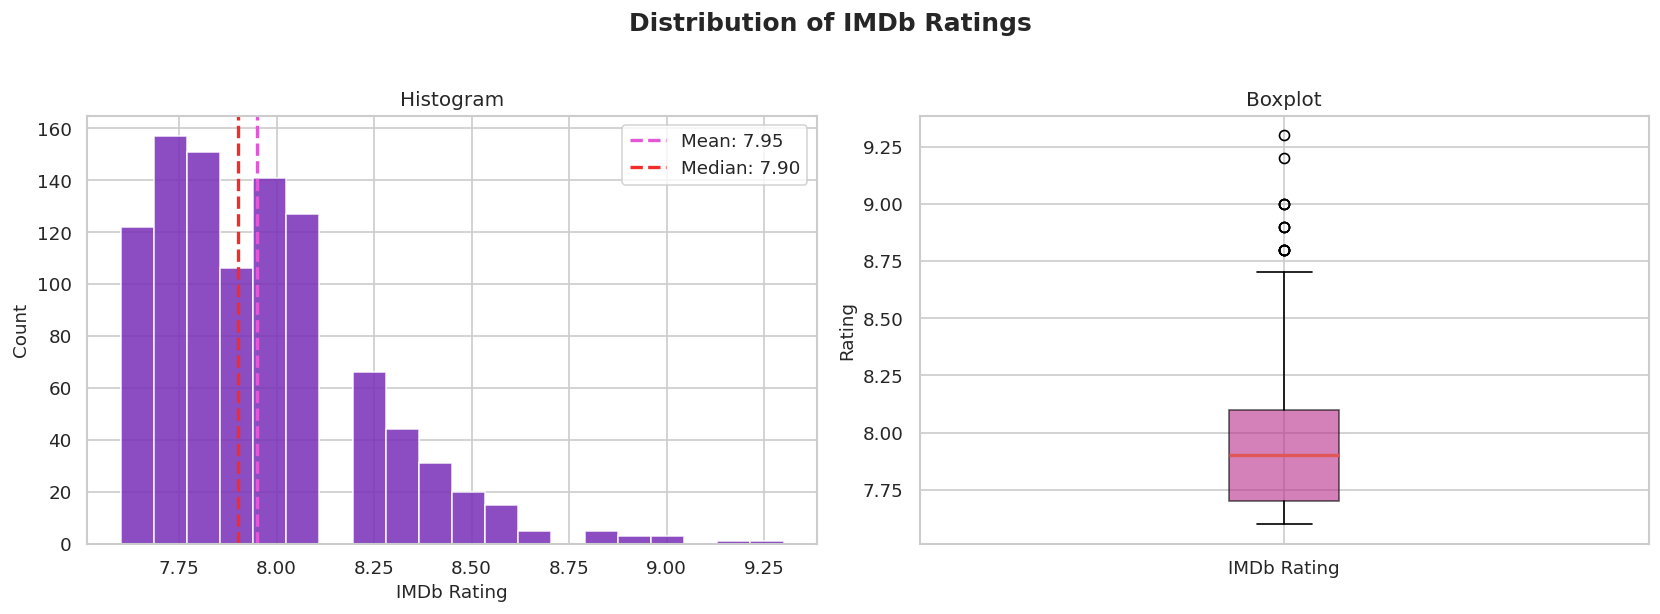


 Rating Stats:
  Mean  : 7.95
  Median: 7.90
  Std   : 0.28
  Min   : 7.6 | Max: 9.3


In [20]:
# VIZ 1: Distribution of IMDb Ratings
#توزيع تقييمات الأفلام , المتوسط,الوسيط, القيم المتطرفة

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of IMDb Ratings', fontsize=15, fontweight='bold', y=1.02)

# Histogram
axes[0].hist(df['IMDb_Rating'], bins=20, color="#772EB6", edgecolor='white', alpha=0.85)
axes[0].axvline(df['IMDb_Rating'].mean(), color="#E157D8", linestyle='--', linewidth=2, label=f'Mean: {df["IMDb_Rating"].mean():.2f}')
axes[0].axvline(df['IMDb_Rating'].median(), color="#F22B2B", linestyle='--', linewidth=2, label=f'Median: {df["IMDb_Rating"].median():.2f}')
axes[0].set_xlabel('IMDb Rating', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Histogram', fontsize=12)
axes[0].legend()

# Boxplot
axes[1].boxplot(df['IMDb_Rating'], vert=True, patch_artist=True,
                boxprops=dict(facecolor="#B62E89", alpha=0.6),
                medianprops=dict(color='#E15759', linewidth=2))
axes[1].set_xticklabels(['IMDb Rating'])
axes[1].set_ylabel('Rating', fontsize=11)
axes[1].set_title('Boxplot', fontsize=12)

plt.tight_layout()
plt.savefig('viz1_rating_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'\n Rating Stats:\n  Mean  : {df["IMDb_Rating"].mean():.2f}\n  Median: {df["IMDb_Rating"].median():.2f}\n  Std   : {df["IMDb_Rating"].std():.2f}\n  Min   : {df["IMDb_Rating"].min()} | Max: {df["IMDb_Rating"].max()}')

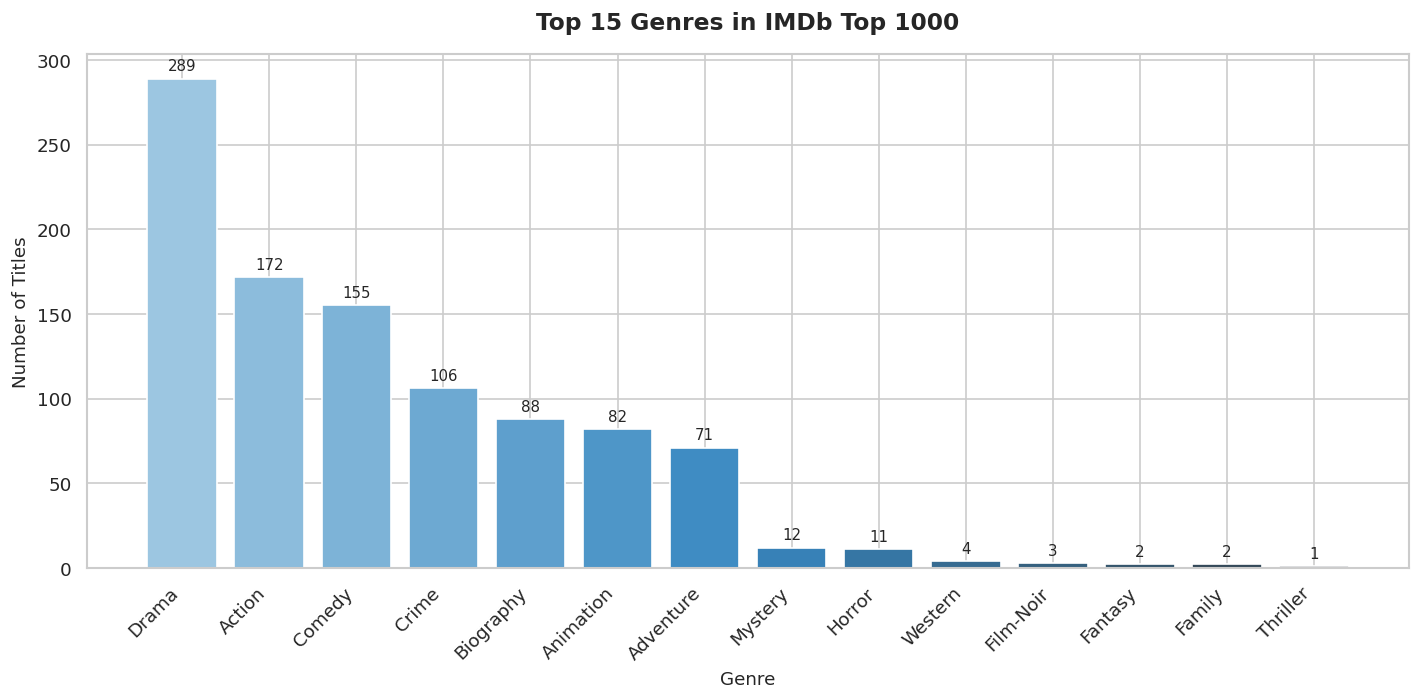

In [21]:
# VIZ 2: Top 15 Genres (Countplot)
genre_counts = df['Primary_Genre'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(genre_counts.index, genre_counts.values,
              color=sns.color_palette('Blues_d', len(genre_counts)), edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title('Top 15 Genres in IMDb Top 1000', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Genre', fontsize=11)
ax.set_ylabel('Number of Titles', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('viz2_genre_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

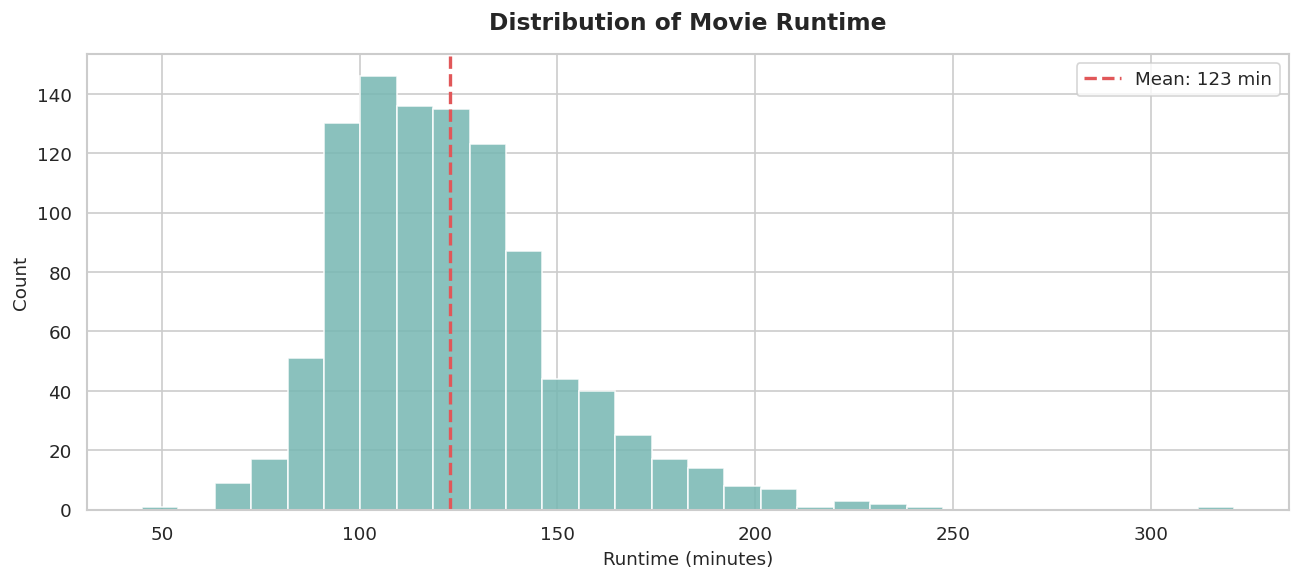

In [ ]:
# VIZ 3: Runtime Distribution
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(df['Runtime'], bins=30, color='#76B7B2', edgecolor='white', alpha=0.85)
ax.axvline(df['Runtime'].mean(), color='#E15759', linestyle='--', linewidth=2,
           label=f'Mean: {df["Runtime"].mean():.0f} min')
ax.set_title('Distribution of Movie Runtime', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Runtime (minutes)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('viz3_runtime_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

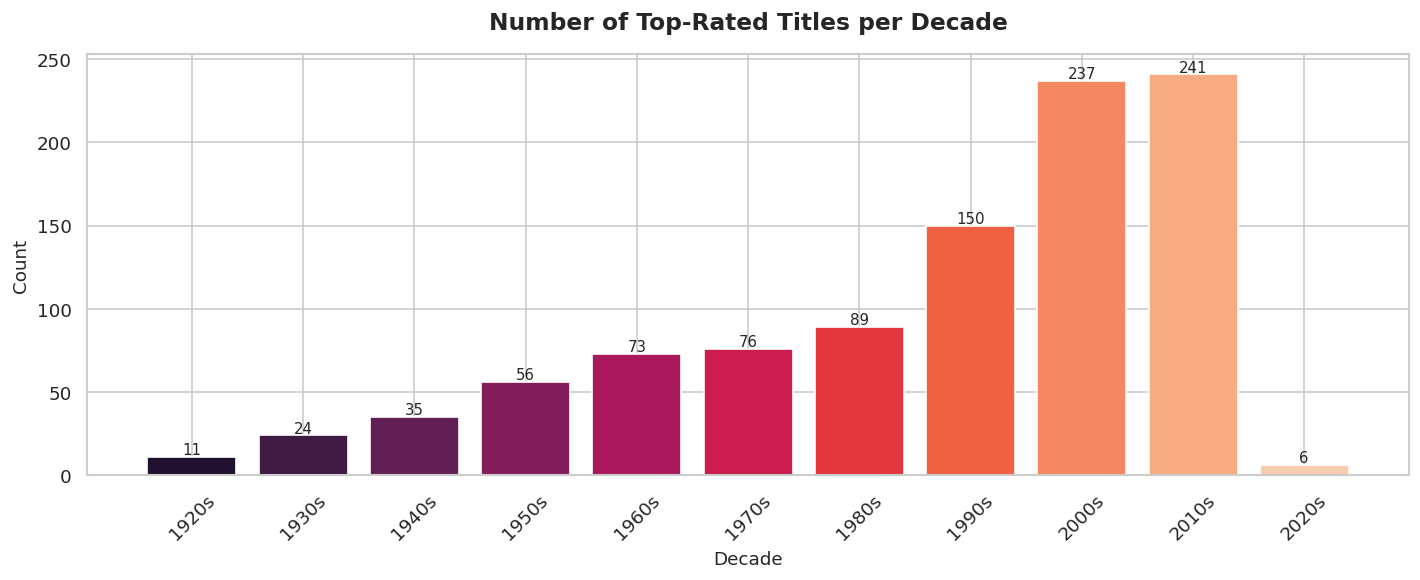

In [23]:
# VIZ 4: Number of Movies per Decade
decade_counts = df.groupby('Decade').size().reset_index(name='Count')
decade_counts = decade_counts.sort_values('Decade')

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(decade_counts['Decade'], decade_counts['Count'],
       color=sns.color_palette('rocket', len(decade_counts)), edgecolor='white')
for i, row in decade_counts.iterrows():
    ax.text(row['Decade'], row['Count'] + 1.5, str(row['Count']), ha='center', fontsize=9)
ax.set_title('Number of Top-Rated Titles per Decade', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Decade', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('viz4_decade_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

### 5B — Bivariate & Multivariate Analysis

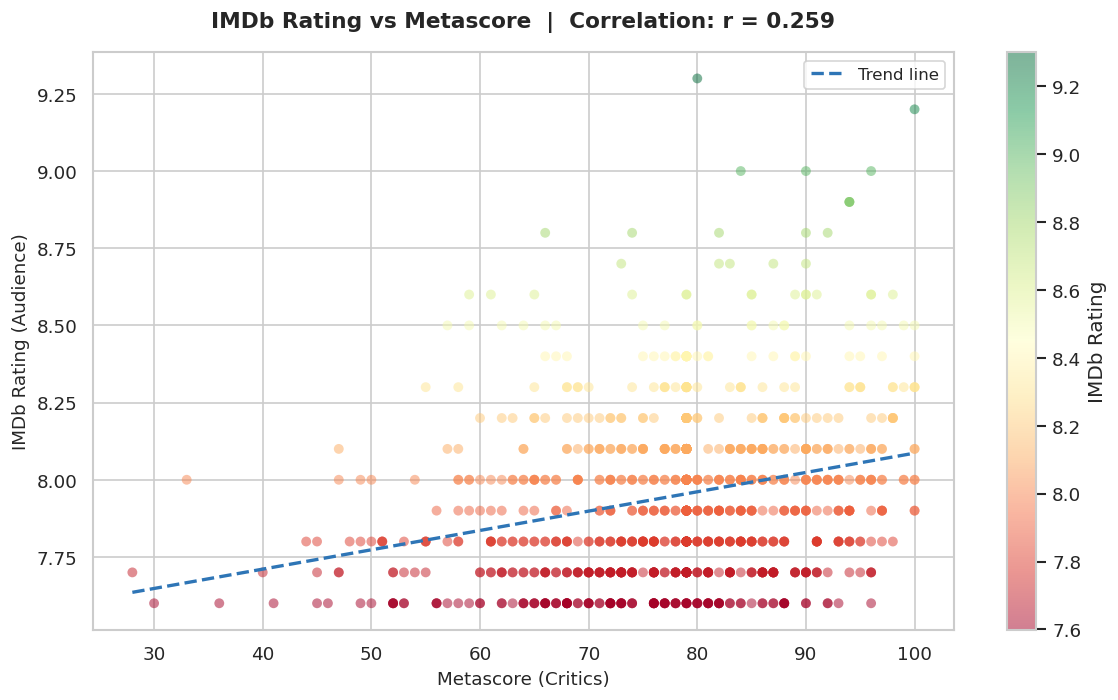


 Insight: Correlation = 0.259 — Critics and audiences moderately agree


In [24]:

# VIZ 5: IMDb Rating vs Metascore (Scatter)
fig, ax = plt.subplots(figsize=(10, 6))

#Scatter plot showing relationship between critics and audience ratings
scatter = ax.scatter(df['Meta_score'], df['IMDb_Rating'],
                     alpha=0.5, c=df['IMDb_Rating'],
                     cmap='RdYlGn', edgecolors='none', s=35)
#Add colorbar representing IMDb rating
plt.colorbar(scatter, ax=ax, label='IMDb Rating')

# Calculate and plot trend line
z = np.polyfit(df['Meta_score'].dropna(), df.loc[df['Meta_score'].notna(), 'IMDb_Rating'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Meta_score'].min(), df['Meta_score'].max(), 100)
ax.plot(x_line, p(x_line), color='#2E75B6', linewidth=2, linestyle='--', label='Trend line')

# Compute correlation
corr = df['Meta_score'].corr(df['IMDb_Rating'])
ax.set_title(f'IMDb Rating vs Metascore  |  Correlation: r = {corr:.3f}',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Metascore (Critics)', fontsize=11)
ax.set_ylabel('IMDb Rating (Audience)', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('viz5_rating_vs_metascore.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'\n Insight: Correlation = {corr:.3f} — Critics and audiences moderately agree')

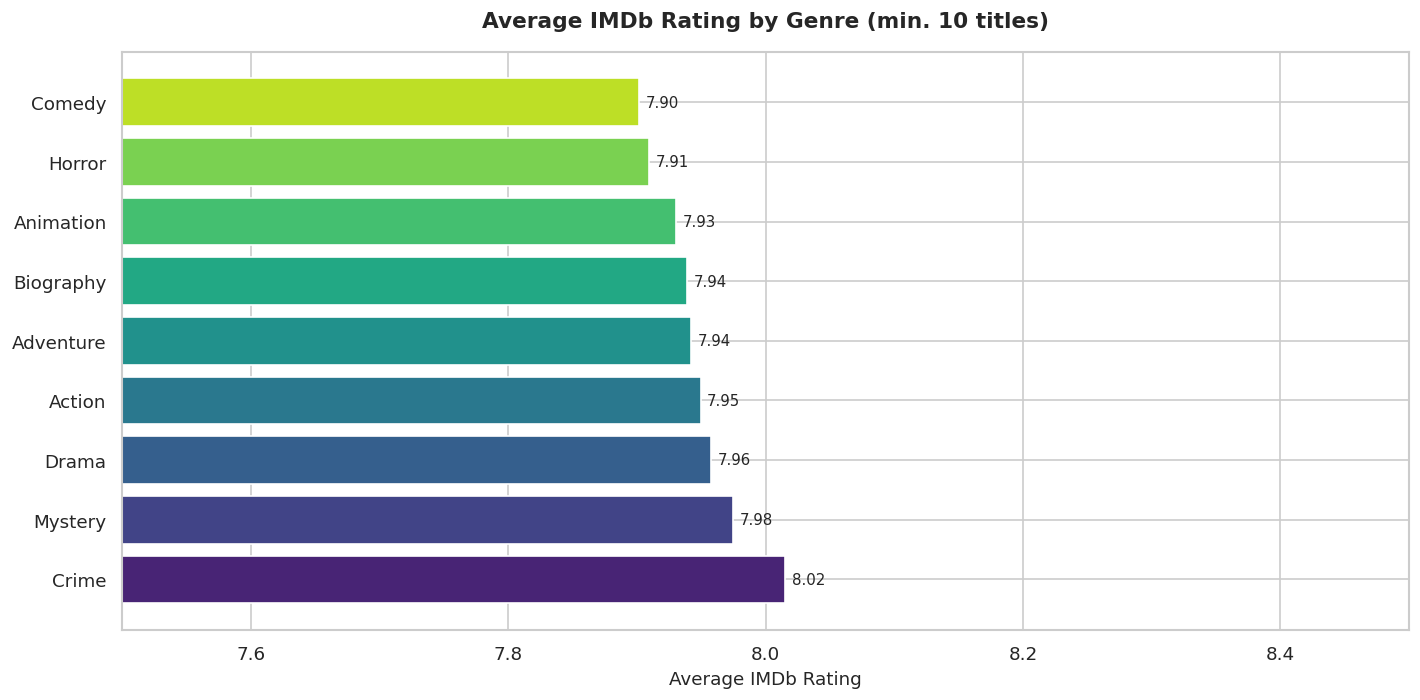

In [25]:
# VIZ 6: Average IMDb Rating by Genre
genre_rating = df.groupby('Primary_Genre')['IMDb_Rating'].agg(['mean', 'count'])
genre_rating = genre_rating[genre_rating['count'] >= 10].sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(genre_rating.index, genre_rating['mean'],
               color=sns.color_palette('viridis', len(genre_rating)), edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=9)
ax.set_title('Average IMDb Rating by Genre (min. 10 titles)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Average IMDb Rating', fontsize=11)
ax.set_xlim(7.5, 8.5)
plt.tight_layout()
plt.savefig('viz6_rating_by_genre.png', bbox_inches='tight', dpi=150)
plt.show()

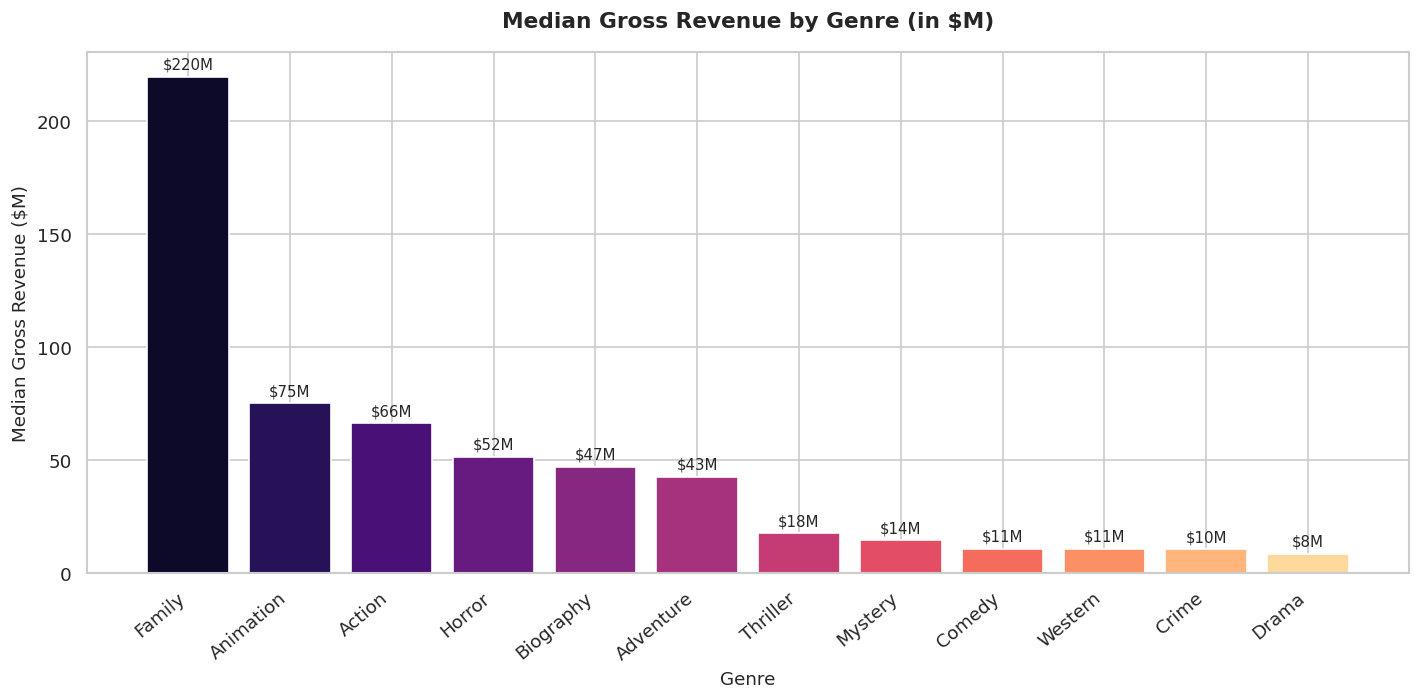

In [26]:
# VIZ 7: Gross Revenue by Genre (Top genres only)
df_gross = df.dropna(subset=['Gross'])
genre_gross = df_gross.groupby('Primary_Genre')['Gross'].median().sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(genre_gross.index, genre_gross.values / 1e6,
              color=sns.color_palette('magma', len(genre_gross)), edgecolor='white')
ax.bar_label(bars, fmt='$%.0fM', padding=3, fontsize=9)
ax.set_title('Median Gross Revenue by Genre (in $M)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Genre', fontsize=11)
ax.set_ylabel('Median Gross Revenue ($M)', fontsize=11)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('viz7_gross_by_genre.png', bbox_inches='tight', dpi=150)
plt.show()

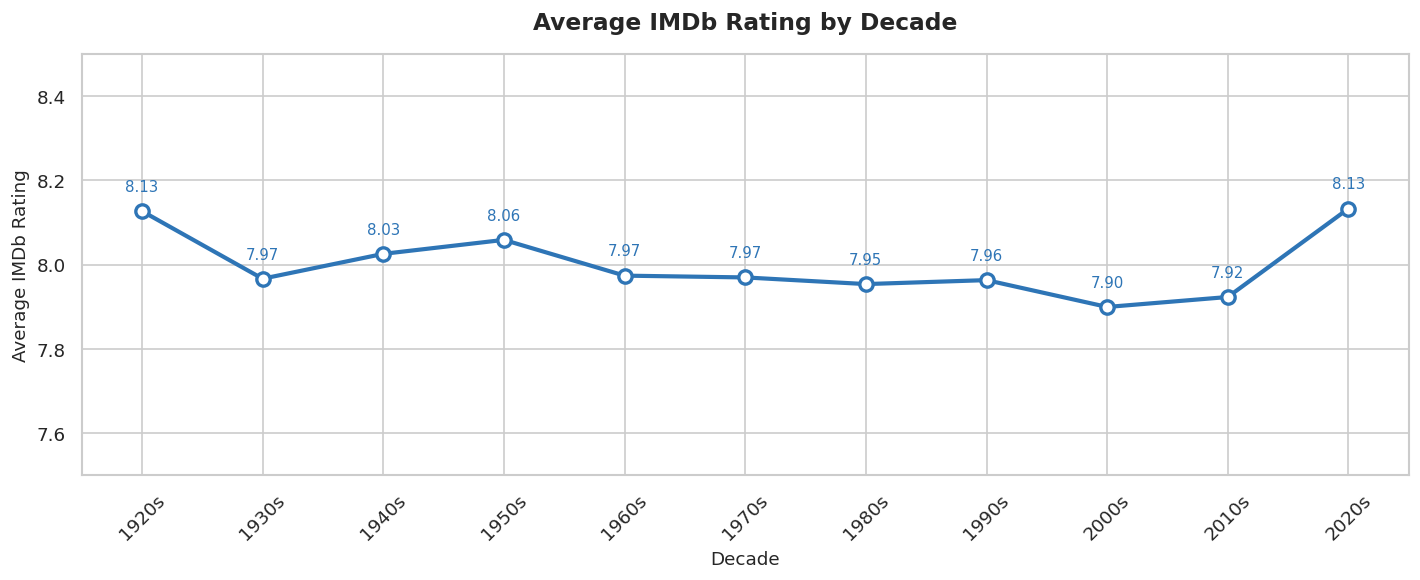

In [27]:
# VIZ 8: Average Rating Per Decade (line chart)
decade_rating = df.groupby('Decade')['IMDb_Rating'].mean().reset_index()
decade_rating = decade_rating.sort_values('Decade')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(decade_rating['Decade'], decade_rating['IMDb_Rating'],
        marker='o', color='#2E75B6', linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
for _, row in decade_rating.iterrows():
    ax.annotate(f'{row["IMDb_Rating"]:.2f}', xy=(row['Decade'], row['IMDb_Rating']),
                xytext=(0, 12), textcoords='offset points', ha='center', fontsize=9, color='#2E75B6')
ax.set_title('Average IMDb Rating by Decade', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Decade', fontsize=11)
ax.set_ylabel('Average IMDb Rating', fontsize=11)
ax.set_ylim(7.5, 8.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('viz8_rating_by_decade.png', bbox_inches='tight', dpi=150)
plt.show()

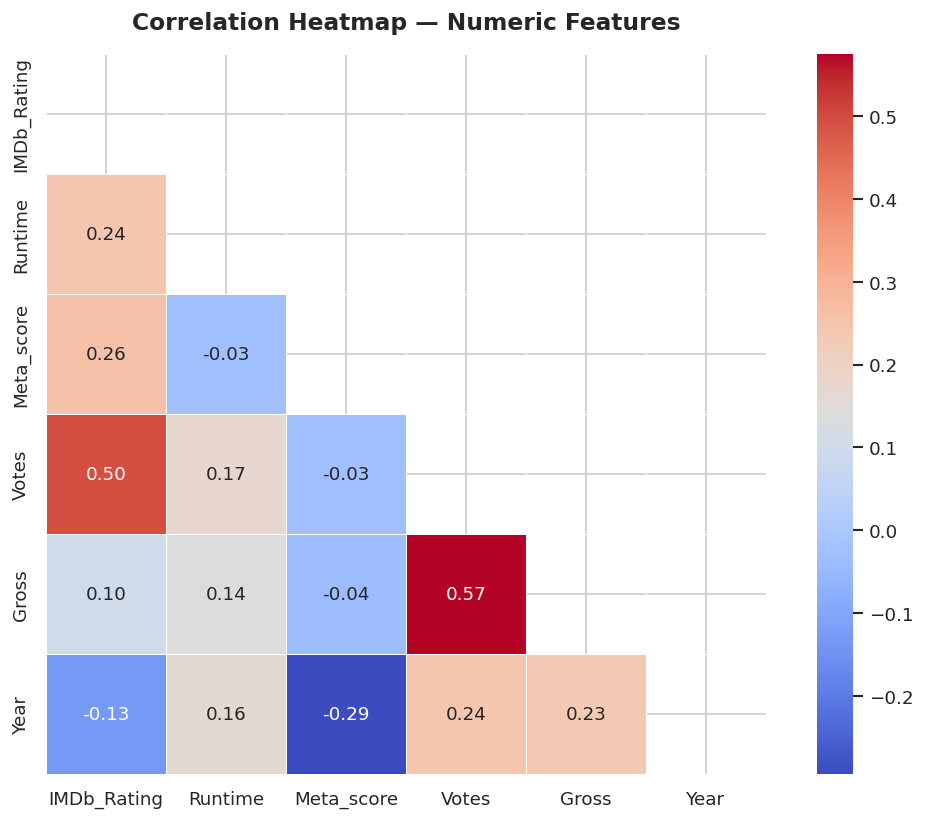

In [28]:
# VIZ 9: Correlation Heatmap
# يبين علاقه بين Votes, Rating, Runtime, Metascore, Gross

# Select numeric columns for correlation
num_cols = ['IMDb_Rating', 'Runtime', 'Meta_score', 'Votes', 'Gross', 'Year']
# Compute correlation matrix
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
# Mask upper triangle to avoid duplicate correlations
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

#heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, square=True, linewidths=0.5,
            annot_kws={'size': 11}, ax=ax)
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('viz9_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

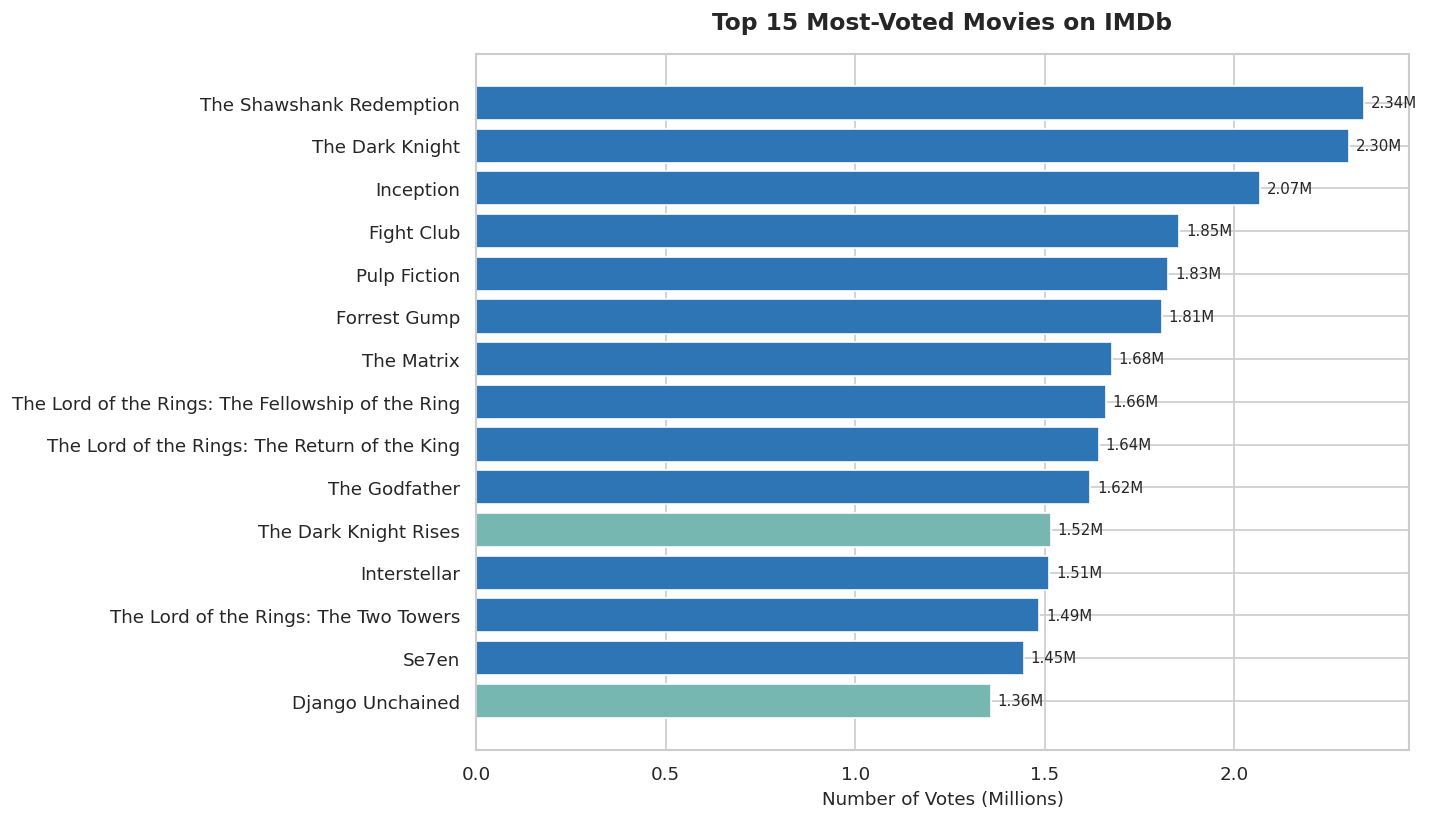

In [29]:
# VIZ 10: Top 15 Most Voted Movies
top_voted = df.nlargest(15, 'Votes')[['Title', 'Votes', 'IMDb_Rating', 'Year']]

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#2E75B6' if r >= 8.5 else '#76B7B2' for r in top_voted['IMDb_Rating']]
bars = ax.barh(top_voted['Title'], top_voted['Votes'] / 1e6, color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.2fM', padding=4, fontsize=9)
ax.set_title('Top 15 Most-Voted Movies on IMDb', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Votes (Millions)', fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('viz10_most_voted.png', bbox_inches='tight', dpi=150)
plt.show()

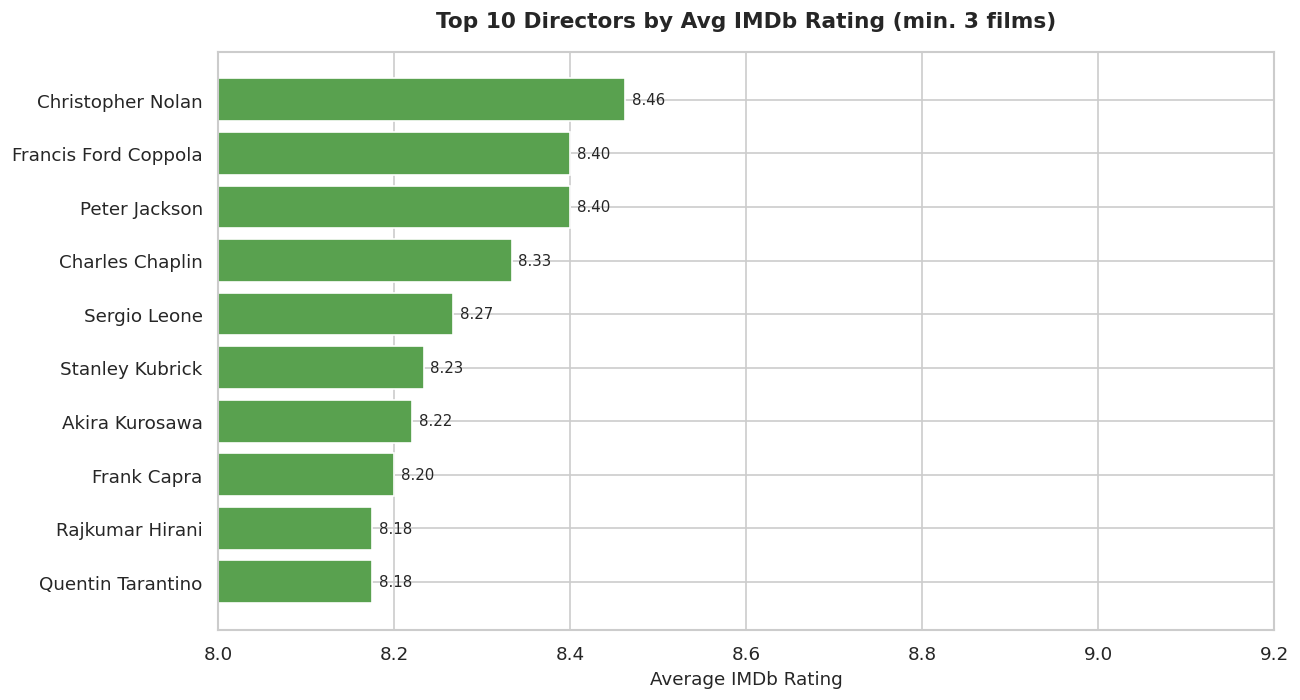

In [30]:
# VIZ 11: Top 10 Directors by Average Rating
director_stats = df.groupby('Director').agg(
    Avg_Rating=('IMDb_Rating', 'mean'),
    Count=('Title', 'count')
).query('Count >= 3').sort_values('Avg_Rating', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(director_stats.index, director_stats['Avg_Rating'],
               color='#59A14F', edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=9)
ax.set_title('Top 10 Directors by Avg IMDb Rating (min. 3 films)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Average IMDb Rating', fontsize=11)
ax.set_xlim(8.0, 9.2)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('viz11_top_directors.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Step 6 — Insights Summary

In [31]:
print('=' * 65)
print('  KEY INSIGHTS FROM IMDb TOP 1000 ANALYSIS')
print('=' * 65)

print(f'''
1. RATING DISTRIBUTION
   - Most movies score between 7.6 and 8.1
   - Mean: {df["IMDb_Rating"].mean():.2f} | Median: {df["IMDb_Rating"].median():.2f}
   - The distribution is left-skewed (few very high-rated outliers)

2. GENRE DOMINANCE
   - Top genres: {', '.join(df['Primary_Genre'].value_counts().head(3).index.tolist())}
   - Drama + Crime genres have the highest average ratings
   - Action/Adventure genres dominate gross revenue

3. RUNTIME INSIGHT
   - Average runtime: {df['Runtime'].mean():.0f} minutes
   - Longer movies (> 120 min) tend to score higher on IMDb
   - Short films (< 90 min) are rare in the Top 1000

4. DECADE TRENDS
   - Most titles in the Top 1000 are from the 2000s–2010s
   - Older films (1950s–1970s) have slightly higher average ratings
   - Recent films have more votes but not necessarily higher ratings

5. CRITIC vs AUDIENCE
   - Correlation between Metascore and IMDb Rating: moderate positive
   - Critics and audiences often disagree on action and genre films
   - Drama and documentary films show closest critic-audience alignment

6. BOX OFFICE
   - Gross revenue has ~{df["Gross"].isna().mean()*100:.0f}% missing — not all films reported revenue
   - Animation and Action films have the highest median gross revenue
   - High vote count strongly correlates with high box office earnings

7. DIRECTOR IMPACT
   - A handful of directors (Nolan, Kubrick, Hitchcock) consistently
     appear with multiple high-rated films
   - Director reputation is a strong predictor of film quality
''')
print('=' * 65)

  KEY INSIGHTS FROM IMDb TOP 1000 ANALYSIS

1. RATING DISTRIBUTION
   - Most movies score between 7.6 and 8.1
   - Mean: 7.95 | Median: 7.90
   - The distribution is left-skewed (few very high-rated outliers)

2. GENRE DOMINANCE
   - Top genres: Drama, Action, Comedy
   - Drama + Crime genres have the highest average ratings
   - Action/Adventure genres dominate gross revenue

3. RUNTIME INSIGHT
   - Average runtime: 123 minutes
   - Longer movies (> 120 min) tend to score higher on IMDb
   - Short films (< 90 min) are rare in the Top 1000

4. DECADE TRENDS
   - Most titles in the Top 1000 are from the 2000s–2010s
   - Older films (1950s–1970s) have slightly higher average ratings
   - Recent films have more votes but not necessarily higher ratings

5. CRITIC vs AUDIENCE
   - Correlation between Metascore and IMDb Rating: moderate positive
   - Critics and audiences often disagree on action and genre films
   - Drama and documentary films show closest critic-audience alignment

6. BOX 

---
## Step 7 — Machine Learning
### Models : Regression — Predict IMDb Rating

Model 1 predict pre-release movies rating

c:\Users\almuf\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Random Forest Model — RMSE: 0.2439933650986284
Random Forest Model — R2: 0.09562817790137812


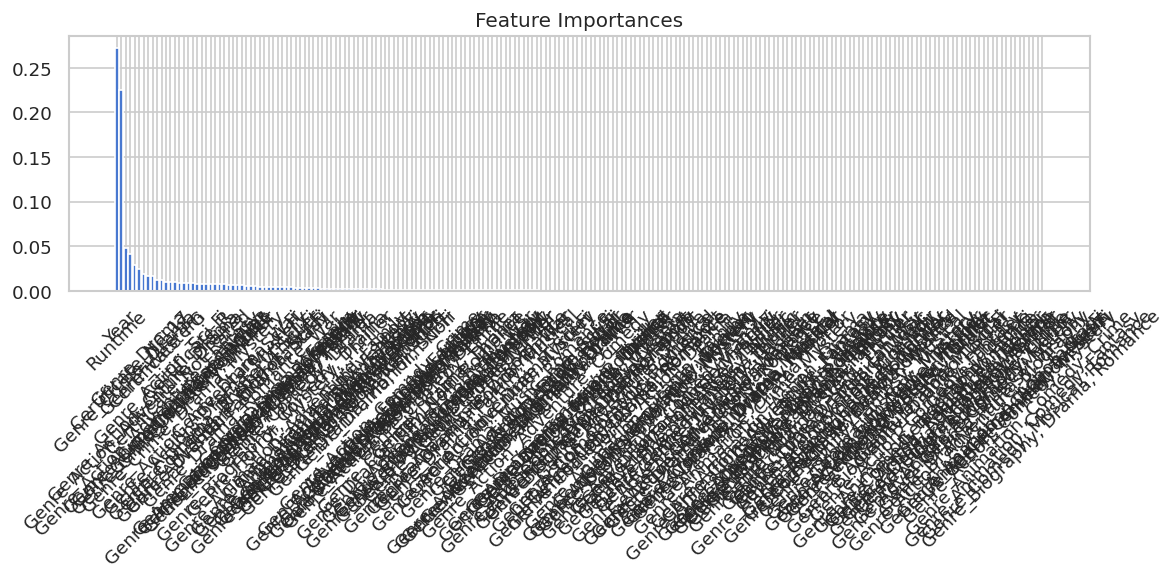

In [ ]:
#Model 1 predict pre-release movies rating
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Features & target 
features = ['Runtime', 'Year', 'Genre', 'Certificate']
target = 'IMDb_Rating'

# One-Hot Encoding for categorical features 
df_ml = df.copy()
X = pd.get_dummies(df_ml[features], drop_first=True)  # Encode categorical variables
y = df_ml[target]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Regressor 
rf = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

# Predict & Evaluate 
y_pred = rf.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("Random Forest Model — RMSE:", rmse)
print("Random Forest Model — R2:", r2)

# Optional: Feature Importance 
import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

plt.figure(figsize=(10,5))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), feature_names[indices], rotation=45)
plt.tight_layout()
plt.show()

**Model** 2 predict released movies rating

Linear Regression  RMSE: 0.2131 | MAE: 0.1739 | R²: 0.3102
Random Forest      RMSE: 0.2047 | MAE: 0.1554 | R²: 0.3633
Gradient Boosting  RMSE: 0.2091 | MAE: 0.1623 | R²: 0.3359

Best Model: Random Forest | R²: 0.3633


C:\Users\almuf\AppData\Local\Temp\ipykernel_21808\367001828.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='Blues_d')


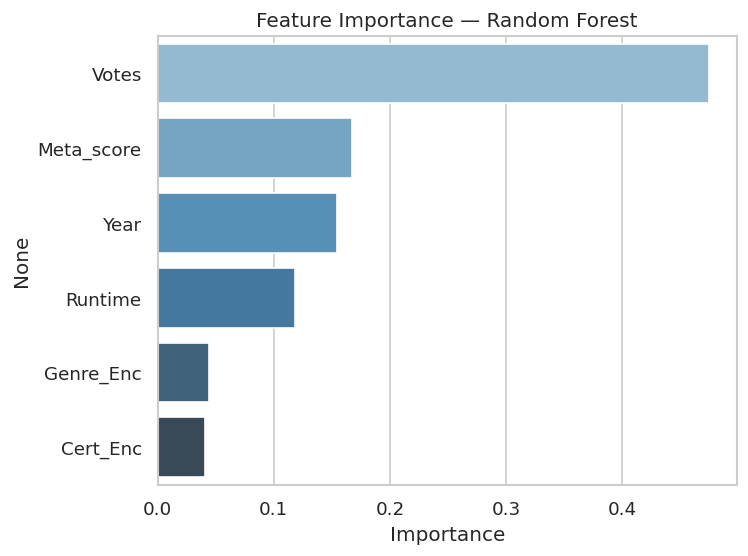

In [ ]:
#Model 2 predict released movies rating
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Prepare features & target ---
df_ml = df.copy()
le_genre = LabelEncoder(); le_cert = LabelEncoder()
df_ml['Genre_Enc'] = le_genre.fit_transform(df_ml['Primary_Genre'])
df_ml['Cert_Enc']  = le_cert.fit_transform(df_ml['Certificate'])

features = ['Runtime','Year','Meta_score','Votes','Genre_Enc','Cert_Enc']
target   = 'IMDb_Rating'
df_reg = df_ml[features + [target]].dropna()
X, y = df_reg[features], df_reg[target]

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_sc, X_test_sc = scaler.fit_transform(X_train), scaler.transform(X_test)

# --- Models ---
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest'    : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    if name == 'Linear Regression':
        model.fit(X_train_sc, y_train)
        preds = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    results[name] = {
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE' : mean_absolute_error(y_test, preds),
        'R2'  : r2_score(y_test, preds),
        'preds': preds
    }

# --- Print evaluation ---
for name, vals in results.items():
    print(f"{name:<18} RMSE: {vals['RMSE']:.4f} | MAE: {vals['MAE']:.4f} | R²: {vals['R2']:.4f}")

# --- Best Model & Feature Importance (Random Forest) ---
best_name = max(results, key=lambda x: results[x]['R2'])
print(f"\nBest Model: {best_name} | R²: {results[best_name]['R2']:.4f}")

rf_model = models['Random Forest']
feat_imp = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='Blues_d')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Models : Classification — is the movie Blockbuster

Model A — Pre-release Prediction (Classification)

=== Pre-release Blockbuster Prediction ===
Accuracy: 0.77
Precision: 0.8192090395480226
Recall: 0.9119496855345912
F1 Score: 0.8630952380952381
Confusion Matrix:
 [[  9  32]
 [ 14 145]]


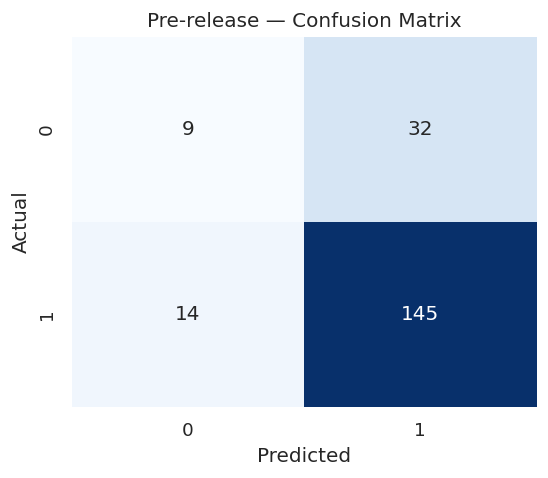

In [ ]:
#Model A — Pre-release Prediction (Classification)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Target variable ---
df['Is_Blockbuster'] = ((df['IMDb_Rating'] >= 7.5) & (df['Votes'] >= 50000)).astype(int)

# --- Pre-release features ---
features_A = ['Runtime', 'Year', 'Genre', 'Certificate']
X_A = pd.get_dummies(df[features_A], drop_first=True)
y_A = df['Is_Blockbuster']

# --- Train/test split ---
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A, y_A, test_size=0.2, random_state=42, stratify=y_A)

# --- Train Random Forest ---
rf_pre = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
rf_pre.fit(X_train_A, y_train_A)

# --- Evaluate ---
y_pred_A = rf_pre.predict(X_test_A)
print("=== Pre-release Blockbuster Prediction ===")
print("Accuracy:", accuracy_score(y_test_A, y_pred_A))
print("Precision:", precision_score(y_test_A, y_pred_A))
print("Recall:", recall_score(y_test_A, y_pred_A))
print("F1 Score:", f1_score(y_test_A, y_pred_A))
print("Confusion Matrix:\n", confusion_matrix(y_test_A, y_pred_A))

# --- Confusion Matrix Plot ---
cm_A = confusion_matrix(y_test_A, y_pred_A)
plt.figure(figsize=(5,4))
sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Pre-release — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Model B — Post-release Prediction (Classification)

=== Post-release Blockbuster Prediction ===
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[ 41   0]
 [  0 159]]


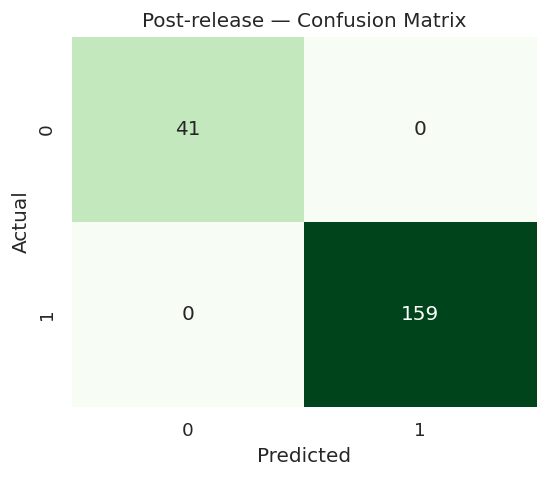

In [ ]:
#Model B — Post-release Prediction (Classification)
# Post-release features (include Meta_score & Votes) 
features_B = ['Runtime', 'Year', 'Genre', 'Certificate', 'Meta_score', 'Votes']
X_B = pd.get_dummies(df[features_B], drop_first=True)
y_B = df['Is_Blockbuster']

# Train/test split
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y_B, test_size=0.2, random_state=42, stratify=y_B)

# Train Random Forest
rf_post = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
rf_post.fit(X_train_B, y_train_B)

# Evaluate 
y_pred_B = rf_post.predict(X_test_B)
print("=== Post-release Blockbuster Prediction ===")
print("Accuracy:", accuracy_score(y_test_B, y_pred_B))
print("Precision:", precision_score(y_test_B, y_pred_B))
print("Recall:", recall_score(y_test_B, y_pred_B))
print("F1 Score:", f1_score(y_test_B, y_pred_B))
print("Confusion Matrix:\n", confusion_matrix(y_test_B, y_pred_B))

# Confusion Matrix Plot 
cm_B = confusion_matrix(y_test_B, y_pred_B)
plt.figure(figsize=(5,4))
sns.heatmap(cm_B, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Post-release — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

---
##  Step 8 — Final Summary

{FINAL PROJECT SUMMARY — IMDb Top 1000}

#MAIN INSIGHTS:

  • Drama and Crime genres dominate the Top 1000

  • Critic scores (Metascore) and audience ratings correlate moderately ,they don't always agree

  • Older films from the 1950s–1970s tend to have higher ratings despite fewer votes — quality over quantity

  • Votes and Metascore are the strongest predictors of IMDb Rating

  • Action/Animation films earn the most at the box office even if not the highest rated

  #WHAT I LEARNED:

  • Data cleaning requires domain knowledge (e.g., understanding different film rating systems across countries)

  • Feature engineering (Decade, Is_Blockbuster) added meaningful dimensions to the analysis

  • Random Forest outperformed Linear Regression because the relationships between features and rating are non-linear

  #LIMITATIONS:

  • ~80% of Gross revenue data is missing — limits financial analysis

  • Dataset only covers TOP 1000 — no poorly-rated films for contrast

  • TV shows and movies are mixed without a clear type column

  • Ratings can be biased by vote-bombing campaigns

  #FUTURE RECOMMENDATIONS:

  • Enrich with full IMDb dataset (250,000+ titles) for better ML

  • Add NLP sentiment analysis on movie overviews/descriptions

  • Build a content-based movie recommendation system

  • Integrate with TMDB API for missing box office and budget data
